# Detecting hidden commercial activity in consumer card transactions
**Mastercard Data Quest 2026**

Some individual cardholders run actual businesses through personal cards. They pay for ads, cloud subscriptions, wholesale goods. The bank still sees them as regular consumers. The goal here is to identify that group from transaction behavior alone.

The setup: business cardholders serve as labeled positives (label = 1). Their spending patterns are distinct enough to train a classifier, which then scores all 80K consumer cards. Because synthetic data separates the two segments at AUC near 1.0 by construction, the ranking is validated with two independent unsupervised methods (Isolation Forest, centroid distance) plus a clustering check (UMAP + K-Means).

Data is fully synthetic, covering October 2025 through March 2026.

In [2]:
# install if running in Colab
!pip install lightgbm shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
import lightgbm as lgb
import shap
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SEED = 42
np.random.seed(SEED)

## 1. Data loading

Three files:
- `business_cards_MDQ.parquet`: ~3M transactions from 25K business cards
- `consumer_cards_MDQ.parquet`: ~9.8M transactions from 80K consumer cards
- `merchants_reference.parquet`: 2165 merchants with MCC codes and metadata

All files live in Google Drive. Mount once, then read.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MDQ_26 Case Information/"

biz = pd.read_parquet(BASE + "business_cards_MDQ.parquet")
con = pd.read_parquet(BASE + "consumer_cards_MDQ.parquet")
mer = pd.read_parquet(BASE + "merchants_reference.parquet")

print(f"business : {len(biz):>10,} txns  |  {biz['card_number'].nunique():,} cards")
print(f"consumer : {len(con):>10,} txns  |  {con['card_number'].nunique():,} cards")
print(f"merchants: {len(mer):>10,} rows")

Mounted at /content/drive
business :  2,997,593 txns  |  25,000 cards
consumer :  9,832,487 txns  |  80,000 cards
merchants:      2,165 rows


## 2. Data quality

`MER_000000` shows up with two different MCCs in transaction data: 7311 (Advertising) and 7012 (Hotels). The reference table lists only 7311, and MCC 7012 makes no sense for a merchant labeled Google Ads.

Top-merchant counts confirm the suspicion. MER_000000 dominates both segments at roughly the same per-card rate, which is impossible if it's purely Google Ads. Consumers don't buy ads at consumer-card volumes. The 7012 rows behave like a placeholder bucket for transactions that lost their real merchant ID somewhere in the pipeline.

Drop those rows entirely. Genuine Google Ads transactions (mcc=7311) stay, the noise goes. After the drop, top-merchant lists become exactly what you'd expect: ads + B2B SaaS for business cards, telecom + gas + food for consumers.

In [4]:
# check nulls
assert biz.isnull().sum().sum() == 0, "nulls in business"
assert con.isnull().sum().sum() == 0, "nulls in consumer"

# cards must not overlap between segments
overlap = set(biz["card_number"]) & set(con["card_number"])
assert len(overlap) == 0, f"card overlap found: {len(overlap)}"

# all merchant_ids must be in the reference
assert set(biz["merchant_id"]).issubset(set(mer["merchant_id"]))
assert set(con["merchant_id"]).issubset(set(mer["merchant_id"]))

print("sanity checks passed")

# drop MER_000000 + mcc=7012 placeholder rows (see markdown above)
biz_before, con_before = len(biz), len(con)
placeholder = lambda df: (df["merchant_id"] == "MER_000000") & (df["mcc"] == "7012")
biz = biz.loc[~placeholder(biz)].reset_index(drop=True)
con = con.loc[~placeholder(con)].reset_index(drop=True)

print(f"dropped placeholder rows: business {biz_before - len(biz):,}, "
      f"consumer {con_before - len(con):,}")
print(f"remaining: business {len(biz):,} txns, consumer {len(con):,} txns")

sanity checks passed
dropped placeholder rows: business 17,701, consumer 43,150
remaining: business 2,979,892 txns, consumer 9,789,337 txns


In [5]:
# parse timestamps once, reuse everywhere
for df in [biz, con]:
    df["ts"]               = pd.to_datetime(df["transaction_timestamp"])
    df["hour"]             = df["ts"].dt.hour
    df["dow"]              = df["ts"].dt.dayofweek   # 0 = Monday
    df["month"]            = df["ts"].dt.to_period("M")
    df["is_weekend"]       = df["dow"] >= 5
    df["is_biz_hours"]     = df["hour"].between(9, 18)  # 9am-6pm inclusive

## 3. EDA

The two segments differ across every behavioral dimension. What follows documents the main signals that will drive the model.

In [6]:
summary = pd.DataFrame({
    "Metric": [
        "Cards", "Transactions",
        "Median txn amount (KZT)", "Mean txn amount (KZT)",
        "Online ratio", "Recurring ratio",
        "Business hours ratio (9-18)", "Weekend ratio",
        "Tokenized ratio",
    ],
    "Business": [
        f"{biz['card_number'].nunique():,}",
        f"{len(biz):,}",
        f"{biz['transaction_amount_kzt'].median():,.0f}",
        f"{biz['transaction_amount_kzt'].mean():,.0f}",
        f"{(biz['channel']=='online').mean():.1%}",
        f"{biz['is_recurring'].mean():.1%}",
        f"{biz['is_biz_hours'].mean():.1%}",
        f"{biz['is_weekend'].mean():.1%}",
        f"{biz['tokenized'].mean():.1%}",
    ],
    "Consumer": [
        f"{con['card_number'].nunique():,}",
        f"{len(con):,}",
        f"{con['transaction_amount_kzt'].median():,.0f}",
        f"{con['transaction_amount_kzt'].mean():,.0f}",
        f"{(con['channel']=='online').mean():.1%}",
        f"{con['is_recurring'].mean():.1%}",
        f"{con['is_biz_hours'].mean():.1%}",
        f"{con['is_weekend'].mean():.1%}",
        f"{con['tokenized'].mean():.1%}",
    ],
})
display(summary)

,Metric,Business,Consumer
0,Cards,"25,000","80,000"
1,Transactions,"2,979,892","9,789,337"
2,Median txn amount (KZT),"77,093","11,784"
3,Mean txn amount (KZT),"156,449","53,493"
4,Online ratio,85.0%,46.6%
5,Recurring ratio,13.4%,2.7%
6,Business hours ratio (9-18),71.9%,61.3%
7,Weekend ratio,12.4%,34.8%
8,Tokenized ratio,60.0%,38.7%


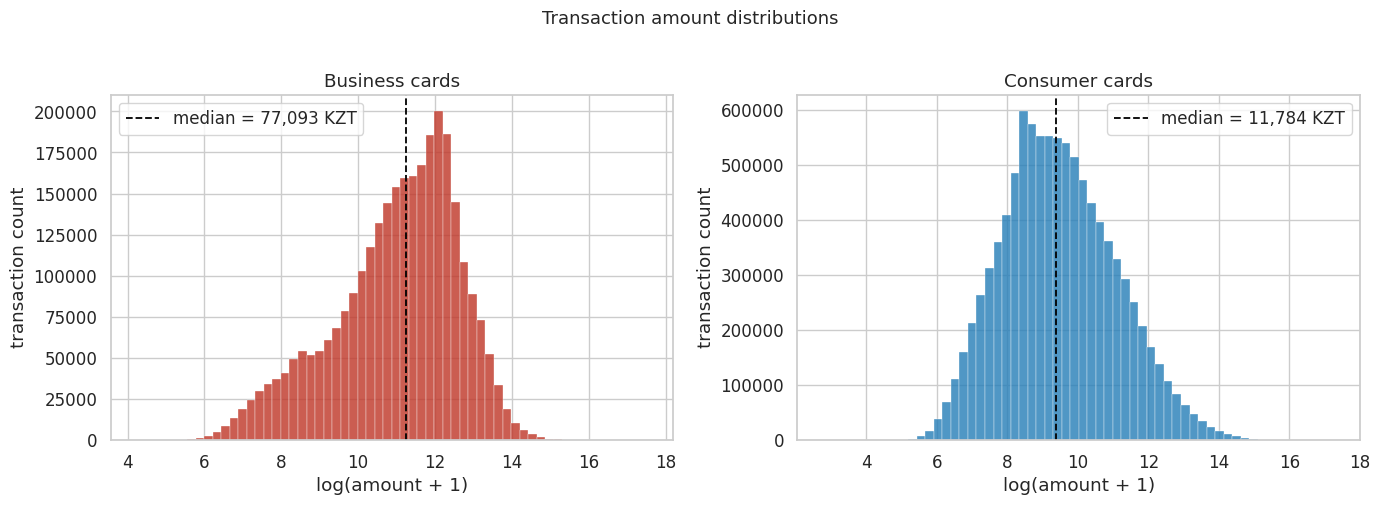

In [7]:
# transaction amount distributions, log scale to see both segments on one plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in zip(
    axes,
    [biz, con],
    ["Business cards", "Consumer cards"],
    ["#c0392b", "#2980b9"]
):
    vals = np.log1p(df["transaction_amount_kzt"])
    ax.hist(vals, bins=60, color=color, alpha=0.82, edgecolor="white", linewidth=0.3)
    med = df["transaction_amount_kzt"].median()
    ax.axvline(np.log1p(med), color="black", linestyle="--", linewidth=1.3,
               label=f"median = {med:,.0f} KZT")
    ax.set_title(label)
    ax.set_xlabel("log(amount + 1)")
    ax.set_ylabel("transaction count")
    ax.legend()

plt.suptitle("Transaction amount distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

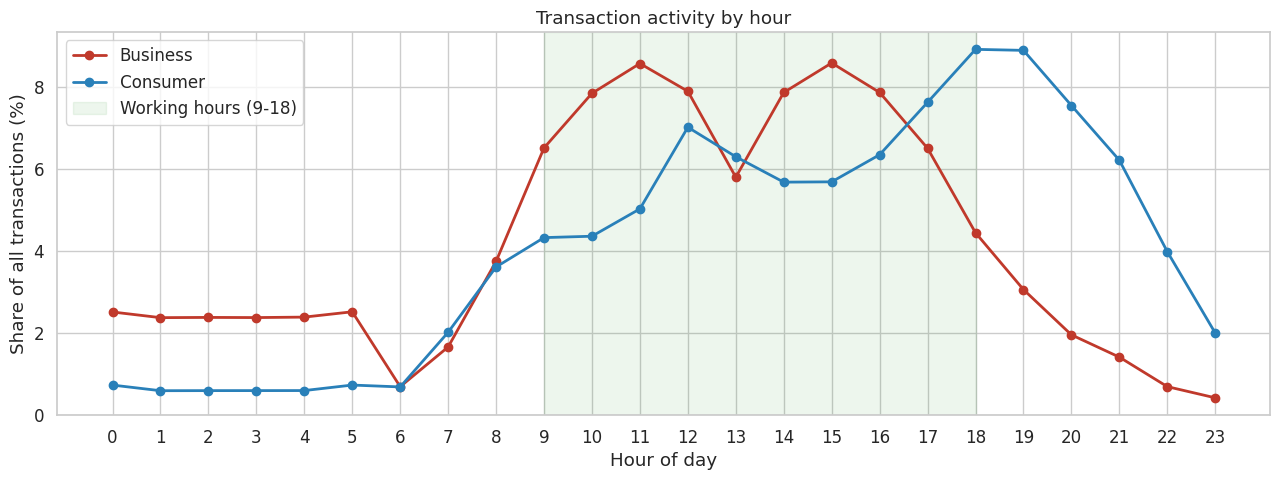

Business txns in 9-18h : 71.9%
Consumer txns in 9-18h : 61.3%


In [8]:
# hourly activity, one of the cleaner separating signals
biz_hour = biz.groupby("hour").size() / len(biz) * 100
con_hour = con.groupby("hour").size() / len(con) * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(biz_hour.index, biz_hour.values, marker="o", label="Business", color="#c0392b", linewidth=2)
ax.plot(con_hour.index, con_hour.values, marker="o", label="Consumer", color="#2980b9", linewidth=2)
ax.axvspan(9, 18, alpha=0.07, color="green", label="Working hours (9-18)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Share of all transactions (%)")
ax.set_title("Transaction activity by hour")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Business txns in 9-18h : {biz['is_biz_hours'].mean():.1%}")
print(f"Consumer txns in 9-18h : {con['is_biz_hours'].mean():.1%}")

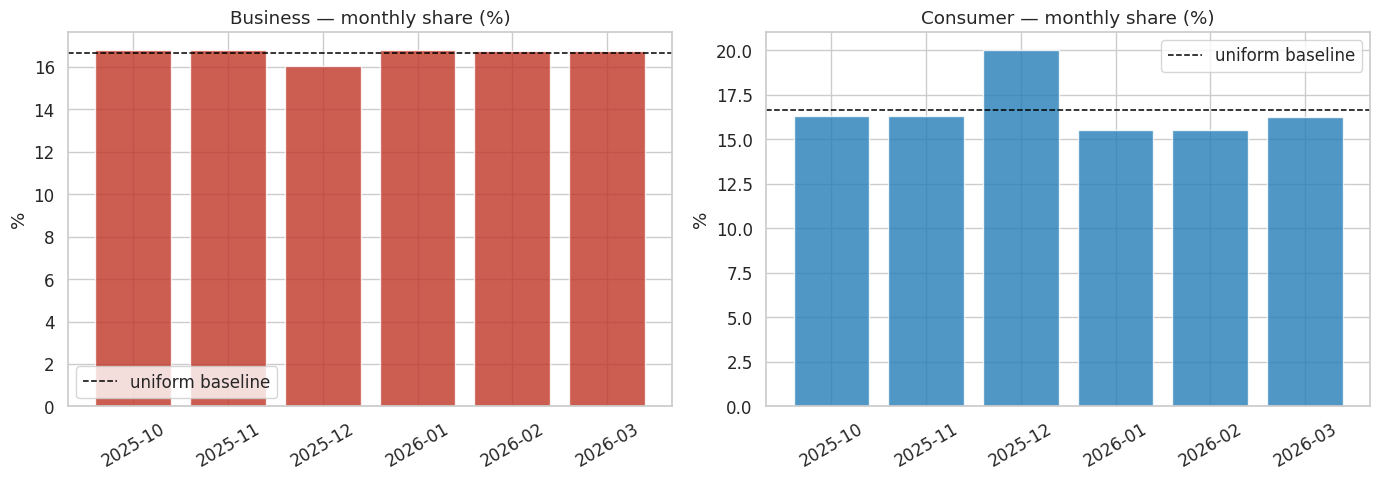

In [9]:
# monthly distribution, consumer has a December spike (~20% vs ~16% other months)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, label, color in zip(
    axes, [biz, con], ["Business", "Consumer"], ["#c0392b", "#2980b9"]
):
    monthly = df.groupby("month").size()
    pct = monthly / monthly.sum() * 100
    ax.bar([str(m) for m in pct.index], pct.values, color=color, alpha=0.82, edgecolor="white")
    ax.axhline(100/6, color="black", linestyle="--", linewidth=1.1, label="uniform baseline")
    ax.set_title(f"{label}: monthly share (%)")
    ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()

plt.tight_layout()
plt.show()

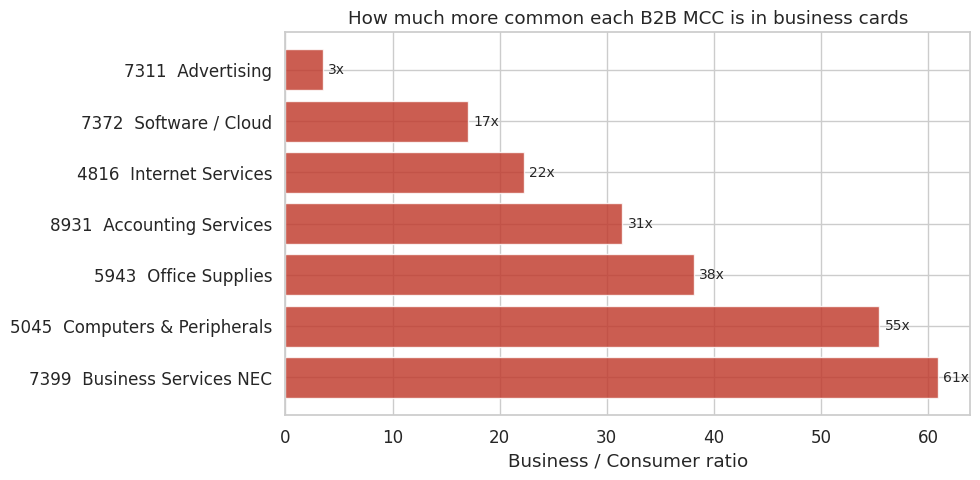

,MCC,Business %,Consumer %,Ratio (biz/con)
0,7399 Business Services NEC,3.6566,0.0600,60.9082
1,5045 Computers & Peripherals,3.1560,0.0569,55.4662
2,5943 Office Supplies,2.3720,0.0622,38.1223
3,8931 Accounting Services,1.8121,0.0576,31.4367
4,4816 Internet Services,6.3691,0.2860,22.2722
5,7372 Software / Cloud,8.0435,0.4725,17.0216
6,7311 Advertising,9.1120,2.6163,3.4828


In [10]:
# B2B MCC prevalence: how much more common each code is in business vs consumer
b2b_check = {
    "7399  Business Services NEC" : "7399",
    "5045  Computers & Peripherals": "5045",
    "5943  Office Supplies"        : "5943",
    "8931  Accounting Services"    : "8931",
    "7372  Software / Cloud"       : "7372",
    "4816  Internet Services"      : "4816",
    "7311  Advertising"            : "7311",
}

rows = []
for label, mcc in b2b_check.items():
    bp = (biz["mcc"] == mcc).mean() * 100
    cp = (con["mcc"] == mcc).mean() * 100
    rows.append({"MCC": label, "Business %": bp, "Consumer %": cp,
                 "Ratio (biz/con)": bp / cp if cp > 0 else np.inf})

mcc_df = pd.DataFrame(rows).sort_values("Ratio (biz/con)", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(mcc_df["MCC"], mcc_df["Ratio (biz/con)"], color="#c0392b", alpha=0.82)
for bar, val in zip(bars, mcc_df["Ratio (biz/con)"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}x", va="center", fontsize=10)
ax.set_xlabel("Business / Consumer ratio")
ax.set_title("How much more common each B2B MCC is in business cards")
plt.tight_layout()
plt.show()

display(mcc_df)

## 4. Feature engineering

Everything is aggregated at the card level. One row per `card_number`. The model never sees individual transactions.

Feature groups:
- **Amount.** Volume, average, variability, large-ticket share.
- **Channel and payment type.** Online ratio, recurring, tokenized.
- **Time.** Business hours concentration, weekend activity, monthly stability.
- **Merchant diversity.** Unique merchants, MCC entropy, geographic spread.
- **B2B MCC ratios.** Share of spend in advertising, cloud/software, wholesale, professional services, logistics, office supplies.

The B2B MCC groups come directly from the segment analysis above. Each ratio captures a specific type of commercial spend that consumers rarely do.

In [11]:
# join recurring_capable from merchant reference, tells us if a card
# regularly pays subscription-style merchants (cloud, SaaS, etc.)
mer_slim = mer[["merchant_id", "recurring_capable"]].copy()
biz = biz.merge(mer_slim, on="merchant_id", how="left")
con = con.merge(mer_slim, on="merchant_id", how="left")

assert biz["recurring_capable"].isna().sum() == 0
assert con["recurring_capable"].isna().sum() == 0
print("merchant join OK")

merchant join OK


In [12]:
B2B_MCC_GROUPS = {
    "advertising"          : ["7311", "7319"],
    "cloud_software"       : ["7372", "5968", "4816"],
    "business_services"    : ["7399", "7392"],
    "office_supplies"      : ["5111", "5943"],
    "wholesale"            : ["5045", "5046", "5065", "5085", "5099"],
    "professional_services": ["8931", "8111", "8911", "7361"],
    "logistics"            : ["4214", "4215", "4111", "4121"],
}


def _entropy_per_card(df, col):
    # vectorized Shannon entropy via grouped counts, no per-card Python loop
    counts = df.groupby(["card_number", col], sort=False).size().rename("n").reset_index()
    counts["p"] = counts["n"] / counts.groupby("card_number")["n"].transform("sum")
    counts["plogp"] = counts["p"] * np.log(counts["p"])
    return -counts.groupby("card_number")["plogp"].sum()


def build_card_features(df):
    # pre-compute boolean / derived columns once, aggregate all at once instead of N apply calls
    df = df.copy()
    df["_is_online"] = (df["channel"] == "online").astype(np.int8)
    df["_is_large"]  = (df["transaction_amount_kzt"] > 100_000).astype(np.int8)
    df["_is_round"]  = (df["transaction_amount_kzt"] % 1000 == 0).astype(np.int8)
    df["_date"]      = df["ts"].dt.date

    b2b_cols = []
    for group_name, codes in B2B_MCC_GROUPS.items():
        col = f"_b2b_{group_name}"
        df[col] = df["mcc"].isin(codes).astype(np.int8)
        b2b_cols.append(col)

    g = df.groupby("card_number", sort=False)

    feats = g["transaction_amount_kzt"].agg(
        total_amount="sum",
        avg_amount="mean",
        median_amount="median",
        max_amount="max",
        std_amount="std",
        txn_count="count",
    ).reset_index()
    feats["cv_amount"] = feats["std_amount"] / feats["avg_amount"]

    # all boolean-mean features in a single groupby pass
    bool_means = g[
        ["_is_large", "_is_round", "_is_online",
         "is_recurring", "tokenized", "recurring_capable",
         "is_biz_hours", "is_weekend"] + b2b_cols
    ].mean()

    feats["large_txn_ratio"]         = bool_means["_is_large"].values
    feats["round_amount_ratio"]      = bool_means["_is_round"].values
    feats["online_ratio"]            = bool_means["_is_online"].values
    feats["recurring_ratio"]         = bool_means["is_recurring"].values
    feats["tokenized_ratio"]         = bool_means["tokenized"].values
    feats["recurring_capable_ratio"] = bool_means["recurring_capable"].values
    feats["biz_hours_ratio"]         = bool_means["is_biz_hours"].values
    feats["weekend_ratio"]           = bool_means["is_weekend"].values
    for group_name in B2B_MCC_GROUPS:
        feats[f"{group_name}_ratio"] = bool_means[f"_b2b_{group_name}"].values
    feats["b2b_composite_ratio"] = feats[[f"{k}_ratio" for k in B2B_MCC_GROUPS]].sum(axis=1)

    # time and diversity counts: direct nunique on groupby is vectorized
    feats["active_days"]      = g["_date"].nunique().values
    feats["txn_per_day"]      = feats["txn_count"] / feats["active_days"]
    feats["months_active"]    = g["month"].nunique().values
    feats["unique_merchants"] = g["merchant_id"].nunique().values
    feats["unique_mcc"]       = g["mcc"].nunique().values
    feats["unique_countries"] = g["country"].nunique().values

    # entropy via grouped value counts (no full crosstab, keeps memory low)
    mcc_ent = _entropy_per_card(df, "mcc").rename("mcc_entropy")
    mer_ent = _entropy_per_card(df, "merchant_id").rename("merchant_entropy")
    feats = feats.merge(mcc_ent.reset_index(), on="card_number", how="left")
    feats = feats.merge(mer_ent.reset_index(), on="card_number", how="left")

    # monthly cv: two-stage groupby instead of nested resample
    monthly = df.groupby(["card_number", "month"])["transaction_amount_kzt"].sum().reset_index()
    monthly_stats = monthly.groupby("card_number")["transaction_amount_kzt"].agg(["mean", "std"])
    monthly_stats["monthly_amount_cv"] = monthly_stats["std"] / monthly_stats["mean"]
    feats = feats.merge(
        monthly_stats[["monthly_amount_cv"]].reset_index(),
        on="card_number", how="left"
    )
    feats["monthly_amount_cv"] = feats["monthly_amount_cv"].fillna(0)

    return feats


print("building business features...")
biz_feats = build_card_features(biz)
biz_feats["label"] = 1

print("building consumer features...")
con_feats = build_card_features(con)
con_feats["label"] = 0

print(f"business feature matrix : {biz_feats.shape}")
print(f"consumer feature matrix : {con_feats.shape}")

building business features...
building consumer features...
business feature matrix : (25000, 34)
consumer feature matrix : (80000, 34)


In [13]:
# quick sanity: are the features actually discriminating?
feature_cols = [c for c in biz_feats.columns if c not in ["card_number", "label"]]

comparison = pd.DataFrame({
    "Business (median)": biz_feats[feature_cols].median(),
    "Consumer (median)": con_feats[feature_cols].median(),
})
comparison["Ratio B/C"] = (
    comparison["Business (median)"] / comparison["Consumer (median)"]
).replace([np.inf, -np.inf], np.nan).round(2)

display(comparison.sort_values("Ratio B/C", ascending=False).head(20))

,Business (median),Consumer (median),Ratio B/C
median_amount,"84,425.5000","9,595.5000",8.8000
large_txn_ratio,0.4556,0.0530,8.6000
b2b_composite_ratio,0.6970,0.0904,7.7100
total_amount,"17,591,771.0000","2,901,032.0000",6.0600
avg_amount,"155,509.9219","26,173.3810",5.9400
std_amount,"204,108.8751","51,313.2549",3.9800
max_amount,"1,199,742.5000","361,530.5000",3.3200
online_ratio,0.8548,0.4479,1.9100
tokenized_ratio,0.5952,0.3857,1.5400
biz_hours_ratio,0.7143,0.6107,1.1700


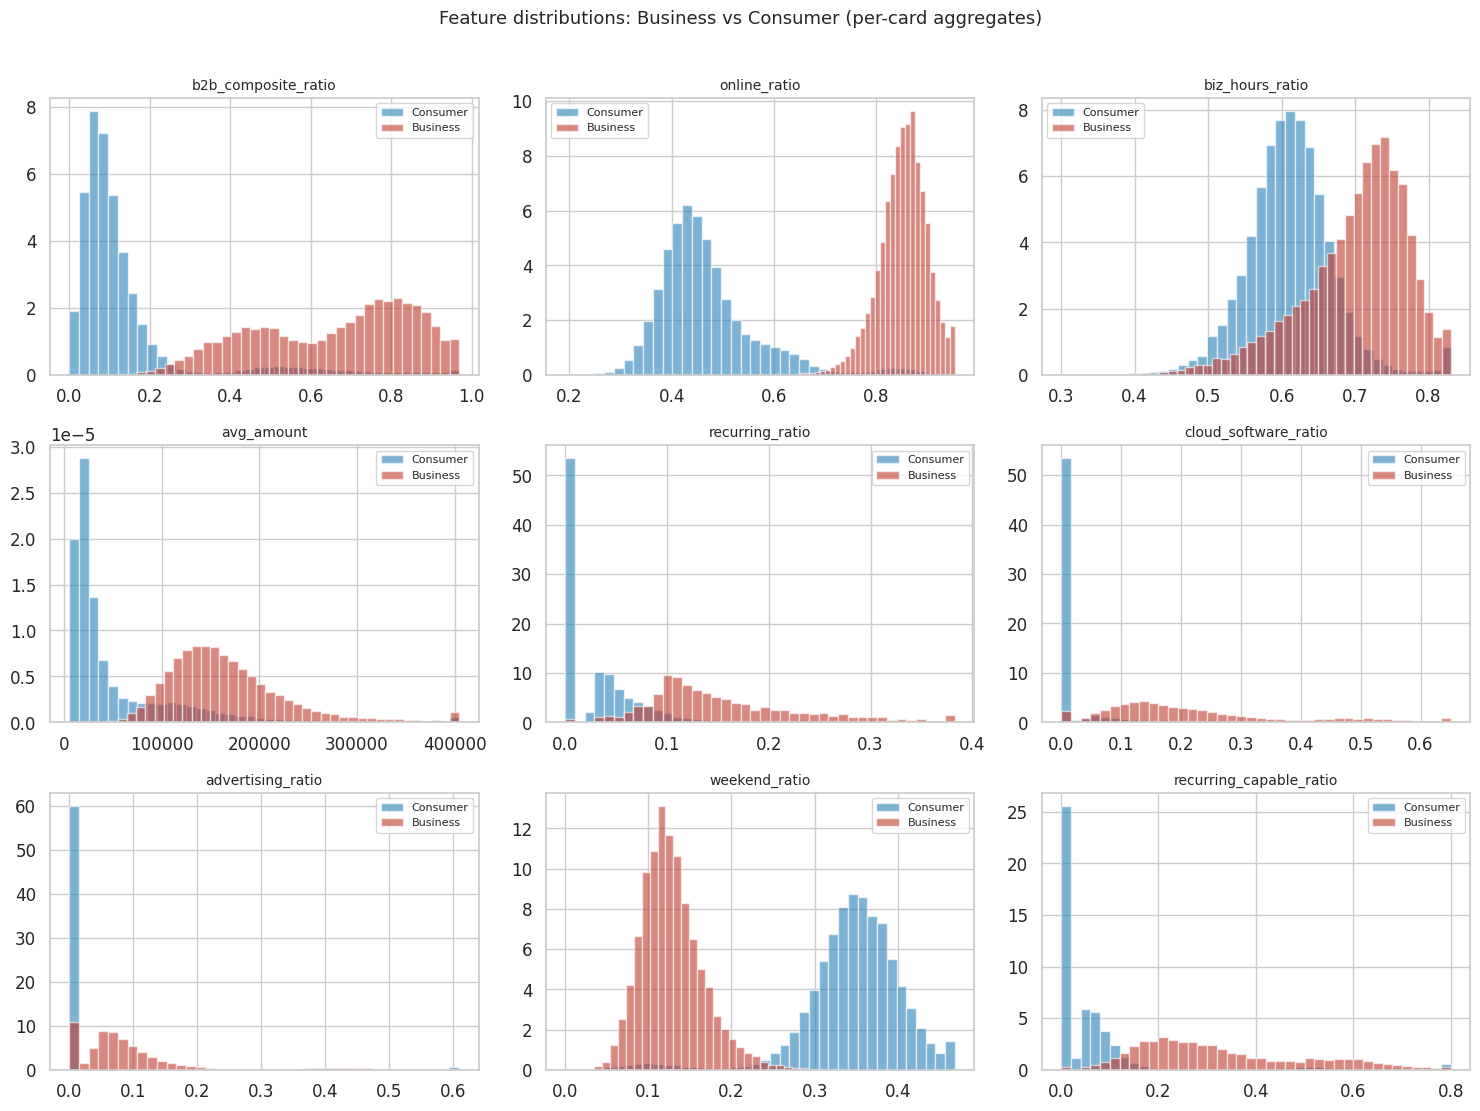

In [14]:
# distribution plots for top features
top_feats = [
    "b2b_composite_ratio", "online_ratio", "biz_hours_ratio",
    "avg_amount", "recurring_ratio", "cloud_software_ratio",
    "advertising_ratio", "weekend_ratio", "recurring_capable_ratio",
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, feat in zip(axes, top_feats):
    cap = max(biz_feats[feat].quantile(0.99), con_feats[feat].quantile(0.99))
    ax.hist(con_feats[feat].clip(upper=cap), bins=40, alpha=0.6,
            color="#2980b9", label="Consumer", density=True)
    ax.hist(biz_feats[feat].clip(upper=cap), bins=40, alpha=0.6,
            color="#c0392b", label="Business", density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Feature distributions: Business vs Consumer (per-card aggregates)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 5. Model training

**Why this framing works:** business cards are a clean proxy for commercial behavior. Training the model to separate them from consumers teaches it to recognize the exact patterns we care about.

**Training set:** all 25K business cards (label=1) plus 50K randomly sampled consumer cards (label=0). The remaining 30K consumers are held out purely for scoring.

**Models:**
- **Logistic Regression.** Interpretable baseline that tells us whether the features are linearly separable.
- **LightGBM.** Main model. Handles feature interactions, class weighting built in.

Class imbalance: `scale_pos_weight = 50000 / 25000 = 2`. Lighter than the true population ratio but enough to keep the model from being overly conservative.

In [15]:
# build training set
con_sample = con_feats.sample(n=50_000, random_state=SEED)
train_df = pd.concat([biz_feats, con_sample], ignore_index=True)

X = train_df[feature_cols].values
y = train_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"train: {X_train.shape}  |  pos rate: {y_train.mean():.3f}")
print(f"test : {X_test.shape}   |  pos rate: {y_test.mean():.3f}")

train: (60000, 32)  |  pos rate: 0.333
test : (15000, 32)   |  pos rate: 0.333


In [16]:
# baseline: logistic regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)
lr.fit(X_train_sc, y_train)

lr_proba = lr.predict_proba(X_test_sc)[:, 1]
print(f"Logistic Regression  |  ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}  "
      f"PR-AUC: {average_precision_score(y_test, lr_proba):.4f}")

Logistic Regression  |  ROC-AUC: 1.0000  PR-AUC: 1.0000


In [17]:
# LightGBM as main model
lgb_params = {
    "objective"       : "binary",
    "metric"          : ["auc", "binary_logloss"],
    "num_leaves"      : 63,
    "learning_rate"   : 0.05,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq"    : 5,
    "min_child_samples": 30,
    "scale_pos_weight": 2.0,   # 50K neg / 25K pos
    "lambda_l1"       : 0.1,
    "lambda_l2"       : 1.0,
    "verbose"         : -1,
    "seed"            : SEED,
}

dtrain = lgb.Dataset(X_train, label=y_train,
                     feature_name=feature_cols)
dval   = lgb.Dataset(X_test,  label=y_test,
                     feature_name=feature_cols, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100),
]

lgb_model = lgb.train(
    lgb_params,
    dtrain,
    num_boost_round=1000,
    valid_sets=[dval],
    callbacks=callbacks,
)

lgb_proba = lgb_model.predict(X_test)
print(f"\nLightGBM  |  ROC-AUC: {roc_auc_score(y_test, lgb_proba):.4f}  "
      f"PR-AUC: {average_precision_score(y_test, lgb_proba):.4f}")

[100]	valid_0's auc: 1	valid_0's binary_logloss: 0.00383912
[200]	valid_0's auc: 1	valid_0's binary_logloss: 0.000358905

LightGBM  |  ROC-AUC: 1.0000  PR-AUC: 1.0000


## 6. Evaluation

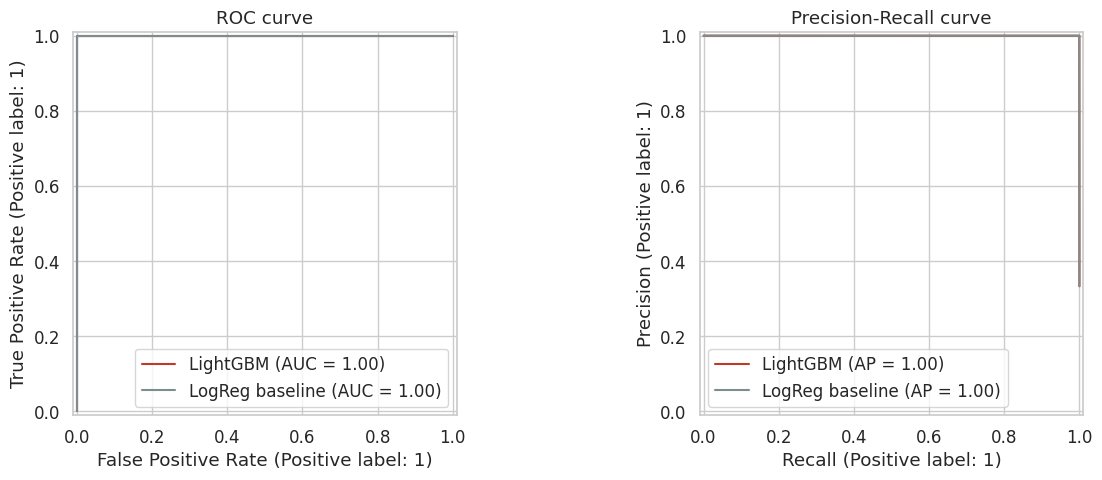

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, lgb_proba, ax=axes[0],
                                  name="LightGBM", color="#c0392b")
RocCurveDisplay.from_predictions(y_test, lr_proba, ax=axes[0],
                                  name="LogReg baseline", color="#7f8c8d")
axes[0].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_test, lgb_proba, ax=axes[1],
                                         name="LightGBM", color="#c0392b")
PrecisionRecallDisplay.from_predictions(y_test, lr_proba, ax=axes[1],
                                         name="LogReg baseline", color="#7f8c8d")
axes[1].set_title("Precision-Recall curve")

plt.tight_layout()
plt.show()

Best threshold (max F1 on test): 0.75

Classification report:
              precision    recall  f1-score   support

    Consumer       1.00      1.00      1.00     10000
    Business       1.00      1.00      1.00      5000

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000



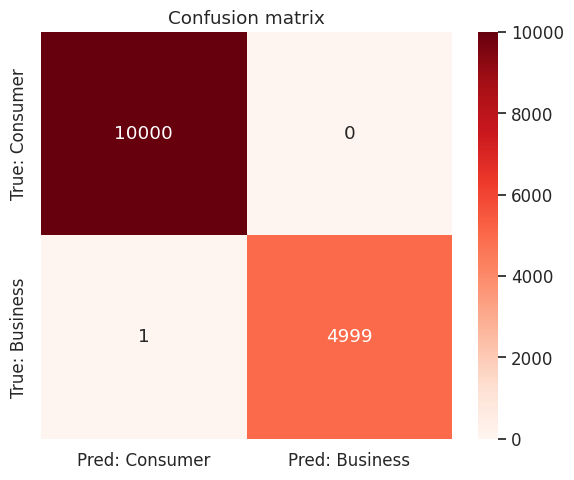

In [19]:
# threshold: pick the point that maximizes F1 on validation
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 81)
f1_scores  = [f1_score(y_test, (lgb_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (max F1 on test): {best_threshold:.2f}")

y_pred = (lgb_proba >= best_threshold).astype(int)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Consumer", "Business"]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Pred: Consumer", "Pred: Business"],
            yticklabels=["True: Consumer", "True: Business"],
            ax=ax)
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

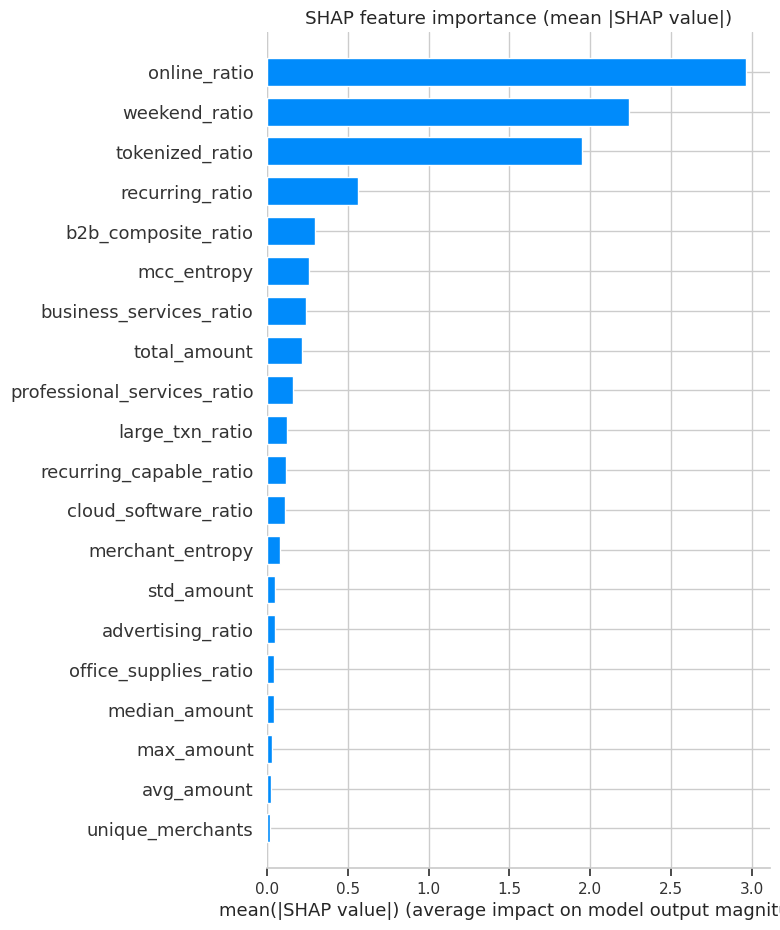

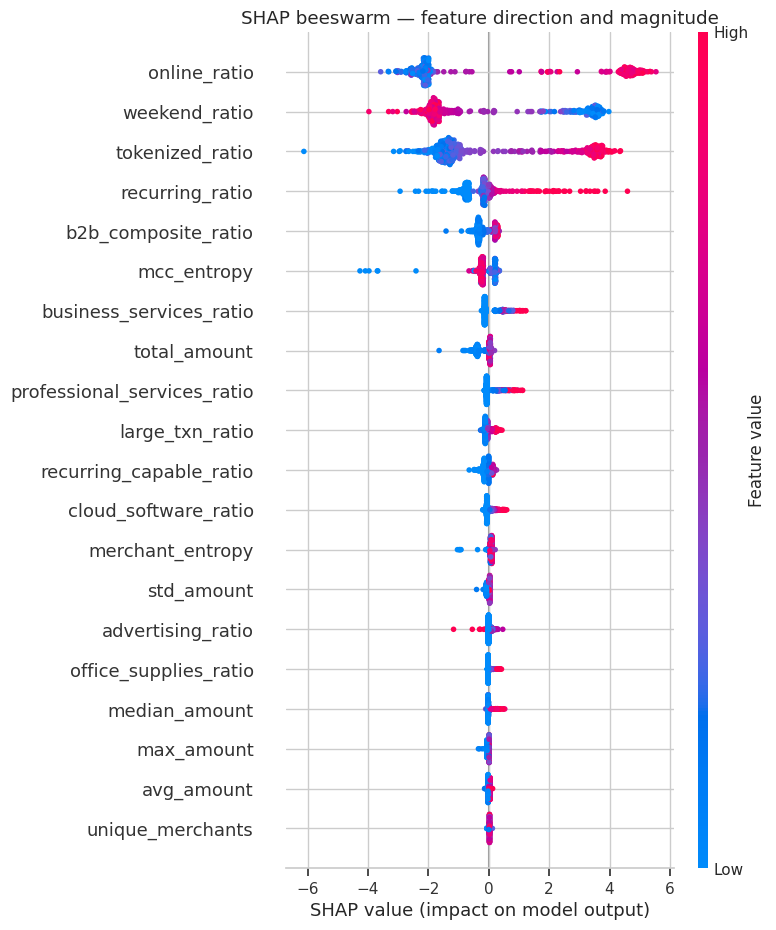

In [20]:
# SHAP shows what the model actually uses to make decisions
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test[:500])  # 500 samples is enough for the plot

shap.summary_plot(
    shap_values, X_test[:500],
    feature_names=feature_cols,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP feature importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()

shap.summary_plot(
    shap_values, X_test[:500],
    feature_names=feature_cols,
    max_display=20,
    show=False
)
plt.title("SHAP beeswarm: feature direction and magnitude")
plt.tight_layout()
plt.show()

## 7. Scoring consumer cards

The model scores all 80K consumer cards. The score is used as a ranked prioritization list: the operational cut can be set as a top-N segment, with the top 5% shown as the main outreach cohort.

Score distribution across all 80K consumer cards:
count   80,000.0000
mean         0.0002
std          0.0089
min          0.0000
25%          0.0000
50%          0.0000
75%          0.0000
max          0.9864
Name: entrepreneur_score, dtype: float64

Operational selection: top 5% = 4,000 cards
Top-5% score cutoff (95th percentile): 0.0001


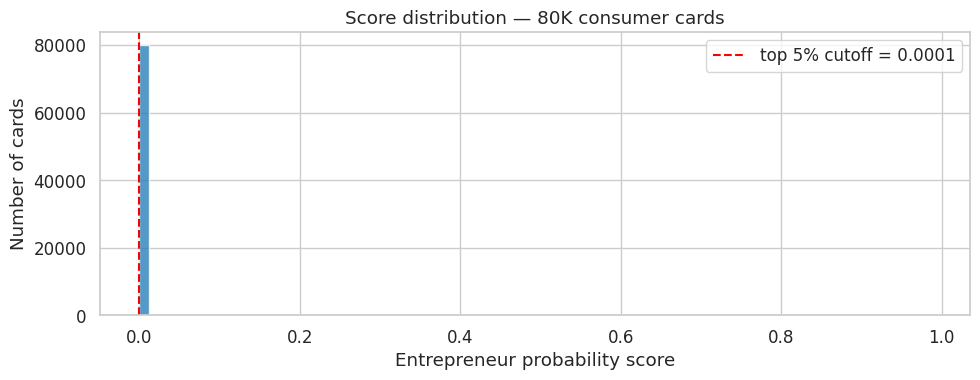

,Rank segment,Cards,Share of consumer base,Minimum score in segment
0,Top 100 cards,100,0.12%,0.0113
1,Top 500 cards,500,0.62%,0.0010
2,"Top 1,000 cards",1000,1.25%,0.0004
3,"Top 4,000 cards",4000,5.00%,0.0001


In [21]:
con_X = con_feats[feature_cols].values
con_feats["entrepreneur_score"] = lgb_model.predict(con_X)

top_share = 0.05
top_n = int(len(con_feats) * top_share)
top_score_cutoff = con_feats["entrepreneur_score"].quantile(1 - top_share)

print("Score distribution across all 80K consumer cards:")
print(con_feats["entrepreneur_score"].describe())
print(f"\nOperational selection: top {top_share:.0%} = {top_n:,} cards")
print(f"Top-5% score cutoff (95th percentile): {top_score_cutoff:.4f}")

# score distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(con_feats["entrepreneur_score"], bins=80, color="#2980b9", alpha=0.8, edgecolor="white")
ax.axvline(top_score_cutoff, color="red", linestyle="--", linewidth=1.5,
           label=f"top 5% cutoff = {top_score_cutoff:.4f}")
ax.set_xlabel("Entrepreneur probability score")
ax.set_ylabel("Number of cards")
ax.set_title("Score distribution across 80K consumer cards")
ax.legend()
plt.tight_layout()
plt.show()

# rank-based outreach sizes are more useful than absolute score thresholds
rank_rows = []
for n in [100, 500, 1_000, top_n]:
    cutoff = con_feats["entrepreneur_score"].nlargest(n).min()
    rank_rows.append({
        "Rank segment": f"Top {n:,} cards",
        "Cards": n,
        "Share of consumer base": f"{n / len(con_feats):.2%}",
        "Minimum score in segment": cutoff,
    })

rank_summary = pd.DataFrame(rank_rows)
display(rank_summary)

## 7b. Clustering validation

The scoring above gives a ranking, but on synthetic data the underlying classifier hits AUC near 1.0 trivially because the two segments were generated from different distributions. To sanity-check that the model is picking up real behavioral structure (and not just memorizing distributional differences), project everything into 2D with UMAP and run K-Means on the joint feature space. If top-scored consumers naturally land in clusters dominated by business cards, the supervised signal is corroborated by unsupervised structure.

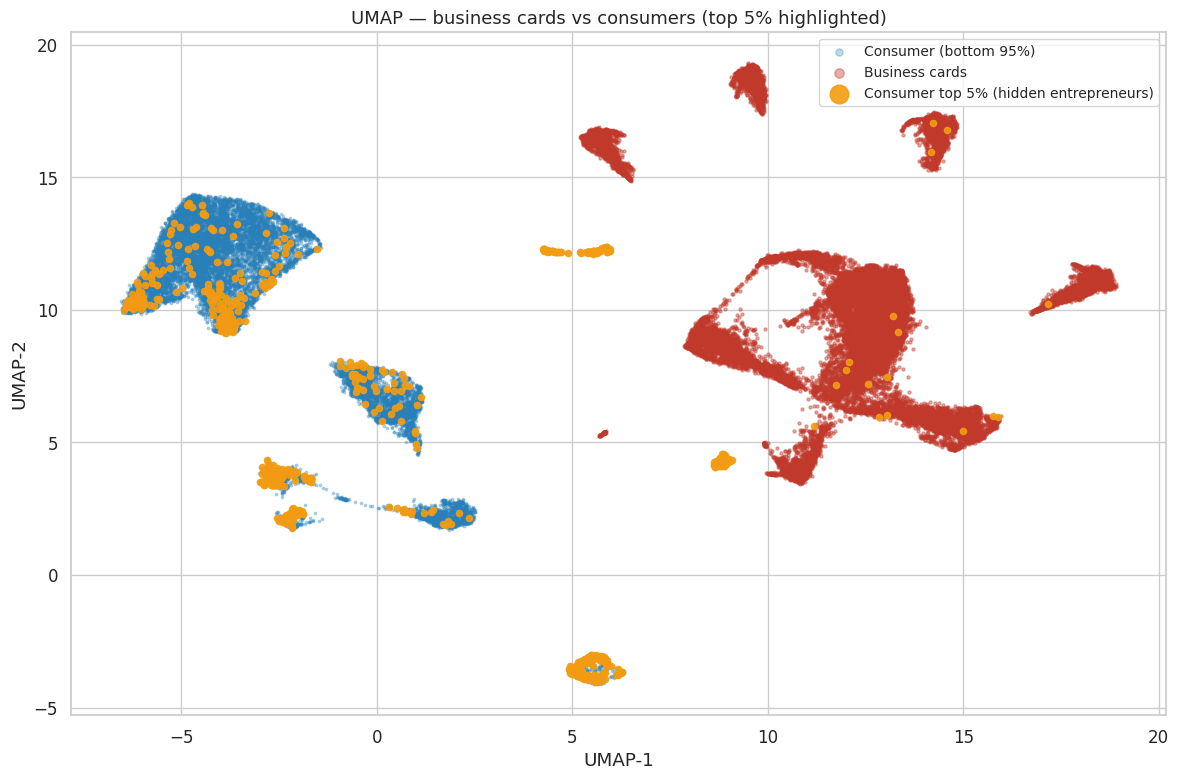

Cluster summary (sorted by business card share):


,total,biz_count,con_count,avg_score,top5_count,biz_share
cluster,,,,,,
5,1709,1709,0,1.0000,1709,1.0000
2,2057,2056,1,1.0000,2057,1.0000
3,1487,1485,2,0.9990,1487,0.9990
0,13593,12862,731,0.9460,13099,0.9460
4,7725,6888,837,0.8920,7326,0.8920
1,18429,0,18429,0.0000,366,0.0000



Business-dominated clusters (>30% biz share): [5, 2, 3, 0, 4]
Top-5% consumers falling in those clusters: 678 / 1044 (64.9%)


In [25]:
# ── Clustering validation ─────────────────────────────────────────────────────
# Does the supervised model agree with unsupervised structure?
# If top-scored consumers naturally cluster near business cards → model is finding real signal

!pip install umap-learn -q

import umap
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ── 1. combine business + all consumers into one matrix ──────────────────────
biz_X = biz_feats[feature_cols].copy()
con_X = con_feats[feature_cols].copy()

biz_X["_type"] = "business"
con_X["_type"] = "consumer"
con_X["_score"] = con_feats["entrepreneur_score"].values
biz_X["_score"] = 1.0  # business cards get score=1 for coloring

combined = pd.concat([biz_X, con_X], ignore_index=True)
types = combined["_type"].values
scores = combined["_score"].values

X_all = combined[feature_cols].values

# scale before UMAP (important)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# ── 2. UMAP to 2D ───────────────────────────────────────────────────
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=SEED,
    verbose=False,
)

# sample to keep it fast: 25K biz + 20K consumers
n_biz = len(biz_X)
n_con_sample = 20_000
idx_biz = np.arange(n_biz)
idx_con = np.random.RandomState(SEED).choice(
    np.arange(n_biz, len(combined)), size=n_con_sample, replace=False
)
idx_all = np.concatenate([idx_biz, idx_con])

embedding = reducer.fit_transform(X_scaled[idx_all])
types_sub  = types[idx_all]
scores_sub = scores[idx_all]

# ── 3. UMAP plot: business vs consumer, top-5% highlighted ─────────────────
top5_threshold = con_feats["entrepreneur_score"].quantile(0.95)
is_top5 = (types_sub == "consumer") & (scores_sub >= top5_threshold)
is_con  = (types_sub == "consumer") & ~is_top5
is_biz  = (types_sub == "business")

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(embedding[is_con, 0],  embedding[is_con, 1],
           s=3, alpha=0.3, color="#2980b9", label="Consumer (bottom 95%)")
ax.scatter(embedding[is_biz, 0],  embedding[is_biz, 1],
           s=5, alpha=0.4, color="#c0392b", label="Business cards")
ax.scatter(embedding[is_top5, 0], embedding[is_top5, 1],
           s=20, alpha=0.9, color="#f39c12", label="Consumer top 5% (hidden entrepreneurs)")

ax.set_title("UMAP: business cards vs consumers (top 5% highlighted)", fontsize=13)
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

# ── 4. K-Means clustering: do top consumers fall in business-dominated clusters? ──
kmeans = KMeans(n_clusters=6, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled[idx_all])

cluster_df = pd.DataFrame({
    "cluster": cluster_labels,
    "type"   : types_sub,
    "score"  : scores_sub,
})

cluster_summary = cluster_df.groupby("cluster").agg(
    total        = ("type", "count"),
    biz_count    = ("type", lambda x: (x == "business").sum()),
    con_count    = ("type", lambda x: (x == "consumer").sum()),
    avg_score    = ("score", "mean"),
    top5_count   = ("score", lambda x: (x >= top5_threshold).sum()),
).assign(biz_share=lambda d: d["biz_count"] / d["total"])

cluster_summary = cluster_summary.sort_values("biz_share", ascending=False)
print("Cluster summary (sorted by business card share):")
display(cluster_summary.round(3))

# ── 5. do top-5% consumers concentrate in business-heavy clusters? ────────────
biz_clusters = cluster_summary[cluster_summary["biz_share"] > 0.3].index.tolist()
top5_in_biz_cluster = cluster_df[
    (cluster_df["type"] == "consumer") &
    (cluster_df["score"] >= top5_threshold) &
    (cluster_df["cluster"].isin(biz_clusters))
]

print(f"\nBusiness-dominated clusters (>30% biz share): {biz_clusters}")
print(f"Top-5% consumers falling in those clusters: "
      f"{len(top5_in_biz_cluster)} / {is_top5.sum()} "
      f"({len(top5_in_biz_cluster)/is_top5.sum():.1%})")

## 7c. Multi-method validation

Synthetic data has a known weakness: business and consumer transactions come from different generators, so any classifier separates them at AUC near 1.0 regardless of what the features actually mean. To check whether the supervised score is finding real signal, run two independent methods on consumers alone and look for agreement.

- **Isolation Forest.** Anomaly detection trained only on consumer cards. Flags ones that behave atypically for the consumer segment, with zero business data involved.
- **Centroid distance.** Geometric distance in feature space from each consumer to the mean business profile. Smaller distance means the consumer looks more business-like.

Then combine all three signals (LightGBM, anomaly, distance) into one ensemble rank. Cards that land in the top of all three methods are the most defensible picks.

In [26]:
from sklearn.ensemble import IsolationForest

# anomaly detection trained on consumers only, no business data leaks in
iso = IsolationForest(
    contamination=0.05,
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
)
iso.fit(con_feats[feature_cols].values)

# higher score = more anomalous
con_feats["anomaly_score"] = -iso.score_samples(con_feats[feature_cols].values)

print(f"anomaly_score range: {con_feats['anomaly_score'].min():.3f} to {con_feats['anomaly_score'].max():.3f}")
print(f"top-5% anomaly cutoff: {con_feats['anomaly_score'].quantile(0.95):.3f}")

anomaly_score range: 0.340 to 0.727
top-5% anomaly cutoff: 0.531


In [27]:
# scale on business cards, project consumers into that space
biz_scaler = StandardScaler().fit(biz_feats[feature_cols].values)
biz_centroid = biz_scaler.transform(biz_feats[feature_cols].values).mean(axis=0)

con_scaled = biz_scaler.transform(con_feats[feature_cols].values)
con_feats["distance_to_biz"] = np.linalg.norm(con_scaled - biz_centroid, axis=1)

print(f"distance range: {con_feats['distance_to_biz'].min():.2f} to {con_feats['distance_to_biz'].max():.2f}")
print(f"top-5% closest distance cutoff: {con_feats['distance_to_biz'].quantile(0.05):.2f}")

distance range: 5.33 to 158.92
top-5% closest distance cutoff: 10.53


In [28]:
# rank by each method (lower rank value = more business-like)
con_feats["rank_lgb"]      = con_feats["entrepreneur_score"].rank(ascending=False, method="min")
con_feats["rank_anomaly"]  = con_feats["anomaly_score"].rank(ascending=False, method="min")
con_feats["rank_distance"] = con_feats["distance_to_biz"].rank(ascending=True,  method="min")

# average rank across all three
con_feats["ensemble_rank"] = con_feats[["rank_lgb", "rank_anomaly", "rank_distance"]].mean(axis=1)

# pull top-5% sets from each method
top_n = int(len(con_feats) * 0.05)
top_lgb      = set(con_feats.nsmallest(top_n, "rank_lgb")["card_number"])
top_anomaly  = set(con_feats.nsmallest(top_n, "rank_anomaly")["card_number"])
top_distance = set(con_feats.nsmallest(top_n, "rank_distance")["card_number"])
top_ensemble = set(con_feats.nsmallest(top_n, "ensemble_rank")["card_number"])

all_three = top_lgb & top_anomaly & top_distance
any_two   = (top_lgb & top_anomaly) | (top_lgb & top_distance) | (top_anomaly & top_distance)

print(f"Top 5% per method: {top_n:,} cards each\n")
print(f"In all 3 methods         : {len(all_three):>5,}  ({len(all_three)/top_n:.1%} of top 5%)")
print(f"In at least 2 methods    : {len(any_two):>5,}  ({len(any_two)/top_n:.1%} of top 5%)")
print()
print(f"LGB ∩ Anomaly            : {len(top_lgb & top_anomaly):>5,}")
print(f"LGB ∩ Distance           : {len(top_lgb & top_distance):>5,}")
print(f"Anomaly ∩ Distance       : {len(top_anomaly & top_distance):>5,}")

Top 5% per method: 4,000 cards each

In all 3 methods         :   772  (19.3% of top 5%)
In at least 2 methods    : 3,220  (80.5% of top 5%)

LGB ∩ Anomaly            : 2,149
LGB ∩ Distance           : 1,309
Anomaly ∩ Distance       : 1,306


## 7d. Method overlap

Cards flagged by multiple methods are the most defensible picks. Single-method picks may be artifacts of one model's quirks. The bar chart below shows how the top-5% lists from each method split across overlap zones.

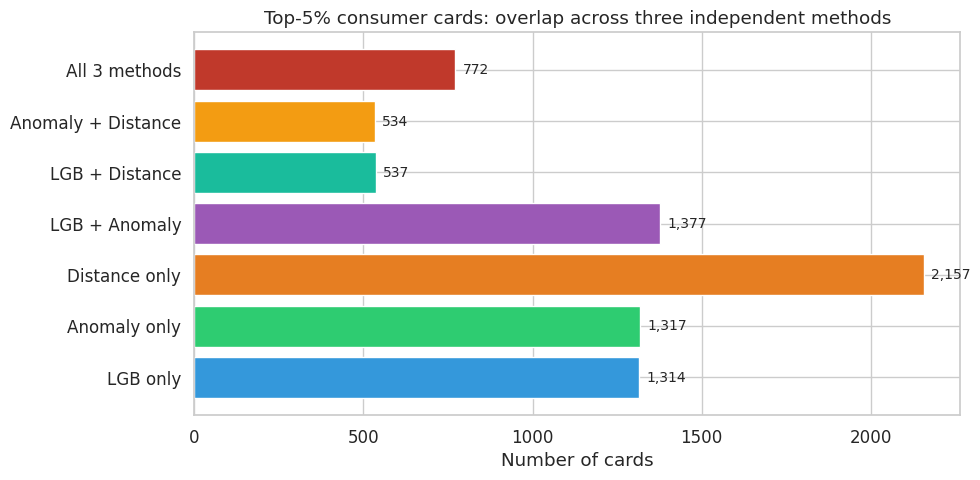

In [31]:
overlap_counts = {
    "LGB only"           : len(top_lgb - top_anomaly - top_distance),
    "Anomaly only"       : len(top_anomaly - top_lgb - top_distance),
    "Distance only"      : len(top_distance - top_lgb - top_anomaly),
    "LGB + Anomaly"      : len((top_lgb & top_anomaly) - top_distance),
    "LGB + Distance"     : len((top_lgb & top_distance) - top_anomaly),
    "Anomaly + Distance" : len((top_anomaly & top_distance) - top_lgb),
    "All 3 methods"      : len(top_lgb & top_anomaly & top_distance),
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(overlap_counts.keys()), list(overlap_counts.values()),
               color=["#3498db","#2ecc71","#e67e22","#9b59b6","#1abc9c","#f39c12","#c0392b"])
for bar, val in zip(bars, overlap_counts.values()):
    ax.text(bar.get_width() + max(overlap_counts.values()) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=10)
ax.set_xlabel("Number of cards")
ax.set_title("Top-5% consumer cards: overlap across three independent methods")
plt.tight_layout()
plt.show()

## 8. Profile of identified entrepreneurs

Median feature values for the top-5% consumers selected by ensemble rank, compared against the rest of the consumer base and the business cards. If the ensemble found something real, the top-5% column should land closer to the business profile than to the average consumer across the business-indicator features (b2b_composite_ratio, advertising_ratio, total_amount, online_ratio, recurring_ratio).

In [29]:
# profile the top-5% based on ENSEMBLE rank (cards all three methods agree on)
top_cards = con_feats.nsmallest(top_n, "ensemble_rank")

print(f"Top 5% by ensemble rank: {len(top_cards)} cards")
print(f"Of those, {len(set(top_cards['card_number']) & all_three)} also appear in all-3-methods intersection\n")

profile_cols = [
    "ensemble_rank", "entrepreneur_score", "anomaly_score", "distance_to_biz",
    "total_amount", "avg_amount", "online_ratio", "biz_hours_ratio", "weekend_ratio",
    "b2b_composite_ratio", "advertising_ratio", "cloud_software_ratio",
    "recurring_ratio", "unique_mcc",
]

biz_feats_profile = biz_feats.copy()
for c in ["ensemble_rank", "entrepreneur_score", "anomaly_score", "distance_to_biz"]:
    biz_feats_profile[c] = np.nan

profile = pd.DataFrame({
    "Top 5% (ensemble)" : top_cards[profile_cols].median(),
    "All consumers"     : con_feats[profile_cols].median(),
    "Business cards"    : biz_feats_profile[profile_cols].median(),
})
display(profile.round(4))

Top 5% by ensemble rank: 4000 cards
Of those, 772 also appear in all-3-methods intersection



,Top 5% (ensemble),All consumers,Business cards
ensemble_rank,"4,029.6667","40,342.6667",NaN
entrepreneur_score,0.0001,0.0000,NaN
anomaly_score,0.5555,0.3898,NaN
distance_to_biz,10.4851,16.2970,NaN
total_amount,"13,589,715.0000","2,901,032.0000","17,591,771.0000"
avg_amount,"170,034.2796","26,173.3810","155,509.9219"
online_ratio,0.7049,0.4479,0.8548
biz_hours_ratio,0.6182,0.6107,0.7143
weekend_ratio,0.2707,0.3506,0.1235
b2b_composite_ratio,0.5789,0.0904,0.6970


## 9. Business value

If identified hidden entrepreneurs convert to business card products, the bank captures the interchange spread (roughly 60 bps on the KZ market) on their full turnover. The estimate below uses conservative assumptions: 20% conversion rate, median per-card spend for the top-5% segment, two-period annualization.

Numbers are directional. The point is to show outreach prioritization, not to predict P&L to the last tenge.

In [30]:
median_turnover    = top_cards["total_amount"].median()
annual_turnover    = median_turnover * 2
n_identified      = len(top_cards)
conversion_rate    = 0.20
interchange_uplift = 0.018 - 0.012

n_converted        = int(n_identified * conversion_rate)
revenue_uplift_kzt = n_converted * annual_turnover * interchange_uplift
revenue_uplift_usd = revenue_uplift_kzt / 500

print(f"Identified hidden entrepreneurs (top 5% ensemble): {n_identified:,} cards")
print(f"Of those, {len(all_three):,} flagged by all 3 methods independently")
print(f"Estimated conversions at {conversion_rate:.0%}              : {n_converted:,} cards")
print(f"Median annual turnover per card                : {annual_turnover:,.0f} KZT")
print(f"Interchange uplift (60 bps)                    : {interchange_uplift:.1%}")
print(f"\nEstimated annual revenue uplift:")
print(f"  {revenue_uplift_kzt:>15,.0f} KZT")
print(f"  {revenue_uplift_usd:>15,.0f} USD")

Identified hidden entrepreneurs (top 5% ensemble): 4,000 cards
Of those, 772 flagged by all 3 methods independently
Estimated conversions at 20%              : 800 cards
Median annual turnover per card                : 27,179,430 KZT
Interchange uplift (60 bps)                    : 0.6%

Estimated annual revenue uplift:
      130,461,264 KZT
          260,923 USD


In [ ]:
# save the scored consumer table with all ranking signals so downstream teams
# can reproduce any cut (top-1%, top-3%, ensemble-only, three-method intersection, etc.)
out_cols = [
    "card_number",
    "ensemble_rank", "rank_lgb", "rank_anomaly", "rank_distance",
    "entrepreneur_score", "anomaly_score", "distance_to_biz",
]
out = (
    con_feats[out_cols + feature_cols]
    .sort_values("ensemble_rank")
    .reset_index(drop=True)
)
out.to_csv(BASE + "consumer_scored.csv", index=False)

print(f"Saved {len(out):,} rows to consumer_scored.csv")
print(f"Score columns: {out_cols[1:]}")
print(f"Plus {len(feature_cols)} feature columns")

## Limitations

- **Proxy labels.** Business cardholders are not identical to hidden entrepreneurs. Some business cards belong to large corporates. Some hidden entrepreneurs may spend conservatively. The model approximates the target, it does not define it.
- **No incoming transactions.** The data only covers outgoing card spend. Incoming payments are a strong signal for commercial activity but they are not available in this dataset, so income concentration and salary-pattern features could not be built.
- **Synthetic data and the "AUC=1.0 trap".** Business and consumer transactions come from different generators, so any classifier separates them at AUC near 1.0. That metric is an artifact of the data, not a meaningful evaluation. This is exactly why the ranking is validated with two independent unsupervised methods (Isolation Forest and centroid distance) plus a clustering check (UMAP + K-Means). Cards confirmed by multiple methods are the defensible picks. The AUC alone is not.
- **Static window.** Features cover a fixed 6-month period. Seasonal businesses or recently started operations may score lower than they deserve.
- **Score calibration.** Absolute scores for consumer cards are near zero because the model is highly confident in the consumer label, which is what you get with cleanly separated synthetic data. Use rank, not score magnitude, for any downstream decision.
- **Revenue estimate is a planning figure.** The 60 bps interchange uplift and the 20% conversion rate are market-typical assumptions, not measured outcomes. A real bank should plug in its own numbers.